Tutorial 7: Results
===================

In the previous tutorials, each search returned a `Result` object, which we used to plot the maximum log likelihood
fit each model-fit. In this tutorial, we'll take a look at the result object in a little more detail.

In [1]:

%matplotlib inline
from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

from pathlib import Path
import autolens as al
import autolens.plot as aplt
import autofit as af

/Users/rosador/Documents/AGEL/autolens_workspace
Working Directory has been set to `/Users/rosador/Documents/AGEL/autolens_workspace`
JAX mode enabled

***JAX ENABLED*** 
    
Using JAX for grad/jit and GPU/TPU acceleration. 
To disable JAX, set: config -> general -> jax -> use_jax = false
    


__Initial Setup__

Lets use the model-fit performed in tutorial 1 to get a `Result` object.

In [2]:
dataset_name = "simple__no_lens_light__mass_sis"
dataset_path = Path("dataset") / "imaging" / dataset_name

dataset = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    psf_path=dataset_path / "psf.fits",
    pixel_scales=0.1,
)

mask_radius = 3.0

mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=mask_radius,
)

dataset = dataset.apply_mask(mask=mask)

model = af.Collection(
    galaxies=af.Collection(
        lens=af.Model(al.Galaxy, redshift=0.5, mass=al.mp.IsothermalSph),
        source=af.Model(al.Galaxy, redshift=1.0, bulge=al.lp.ExponentialCoreSph),
    ),
)

search = af.Nautilus(
    path_prefix=Path("howtolens") / "chapter_2",
    name="tutorial_1_non_linear_search",
    unique_tag=dataset_name,
    n_live=80,
)

analysis = al.AnalysisImaging(dataset=dataset)

result = search.fit(model=model, analysis=analysis)

2025-10-24 17:13:14,701 - jax._src.xla_bridge - INFO - Unable to initialize backend 'cuda': 
2025-10-24 17:13:14,701 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-10-24 17:13:14,702 - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/autolens/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
2025-10-24 17:13:15,011 - autoarray.dataset.imaging.dataset - INFO - Imaging data has been trimmed or padded for FFT convolution.
  - Original shape : (100, 100)
  - FFT shape    : (80, 80)
Padding ensures accurate PSF convolution in Fourier sp

__Tracer & Fit__

In the previous tutorials, we saw that this result contains the maximum log likelihood fit, which provide
a fast way to visualize the result.

It also contains the maximum log likelihood tracer.

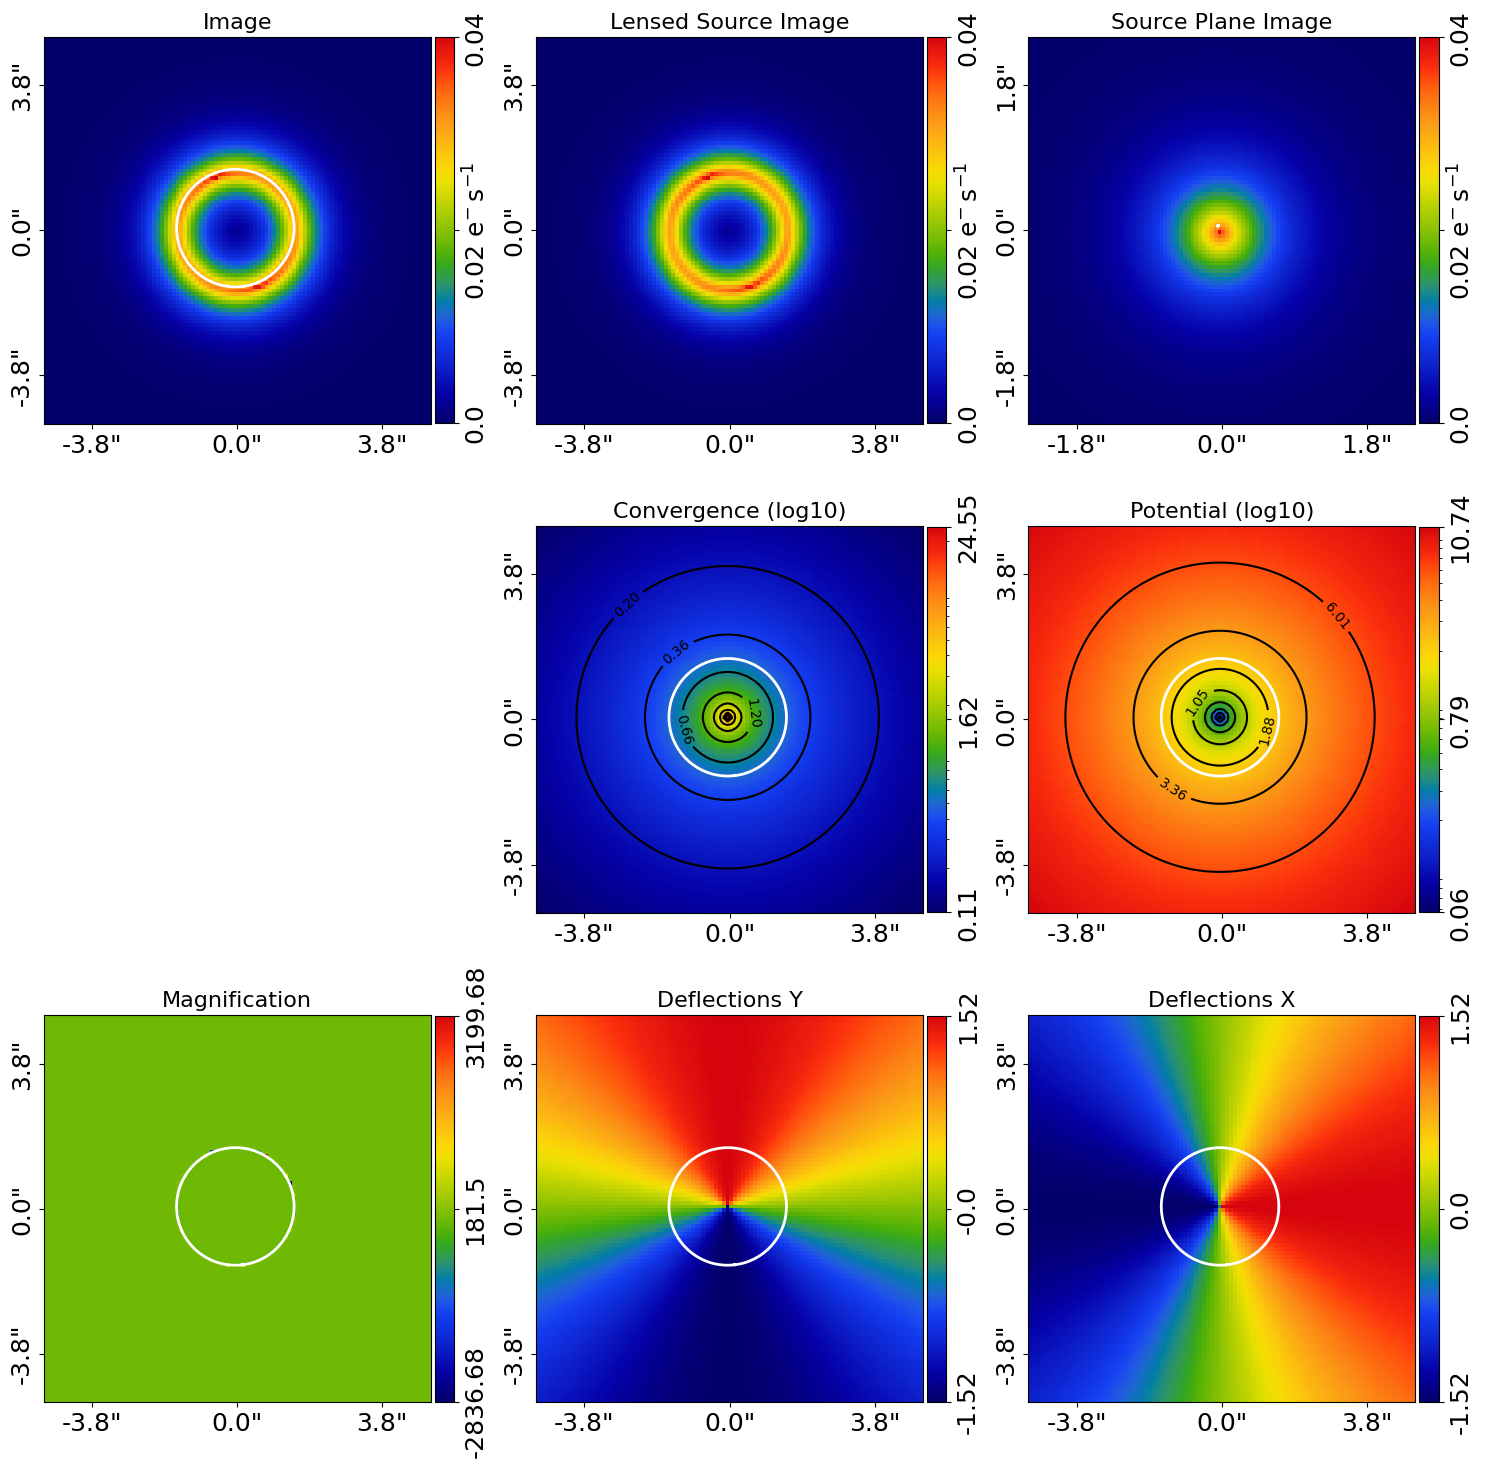

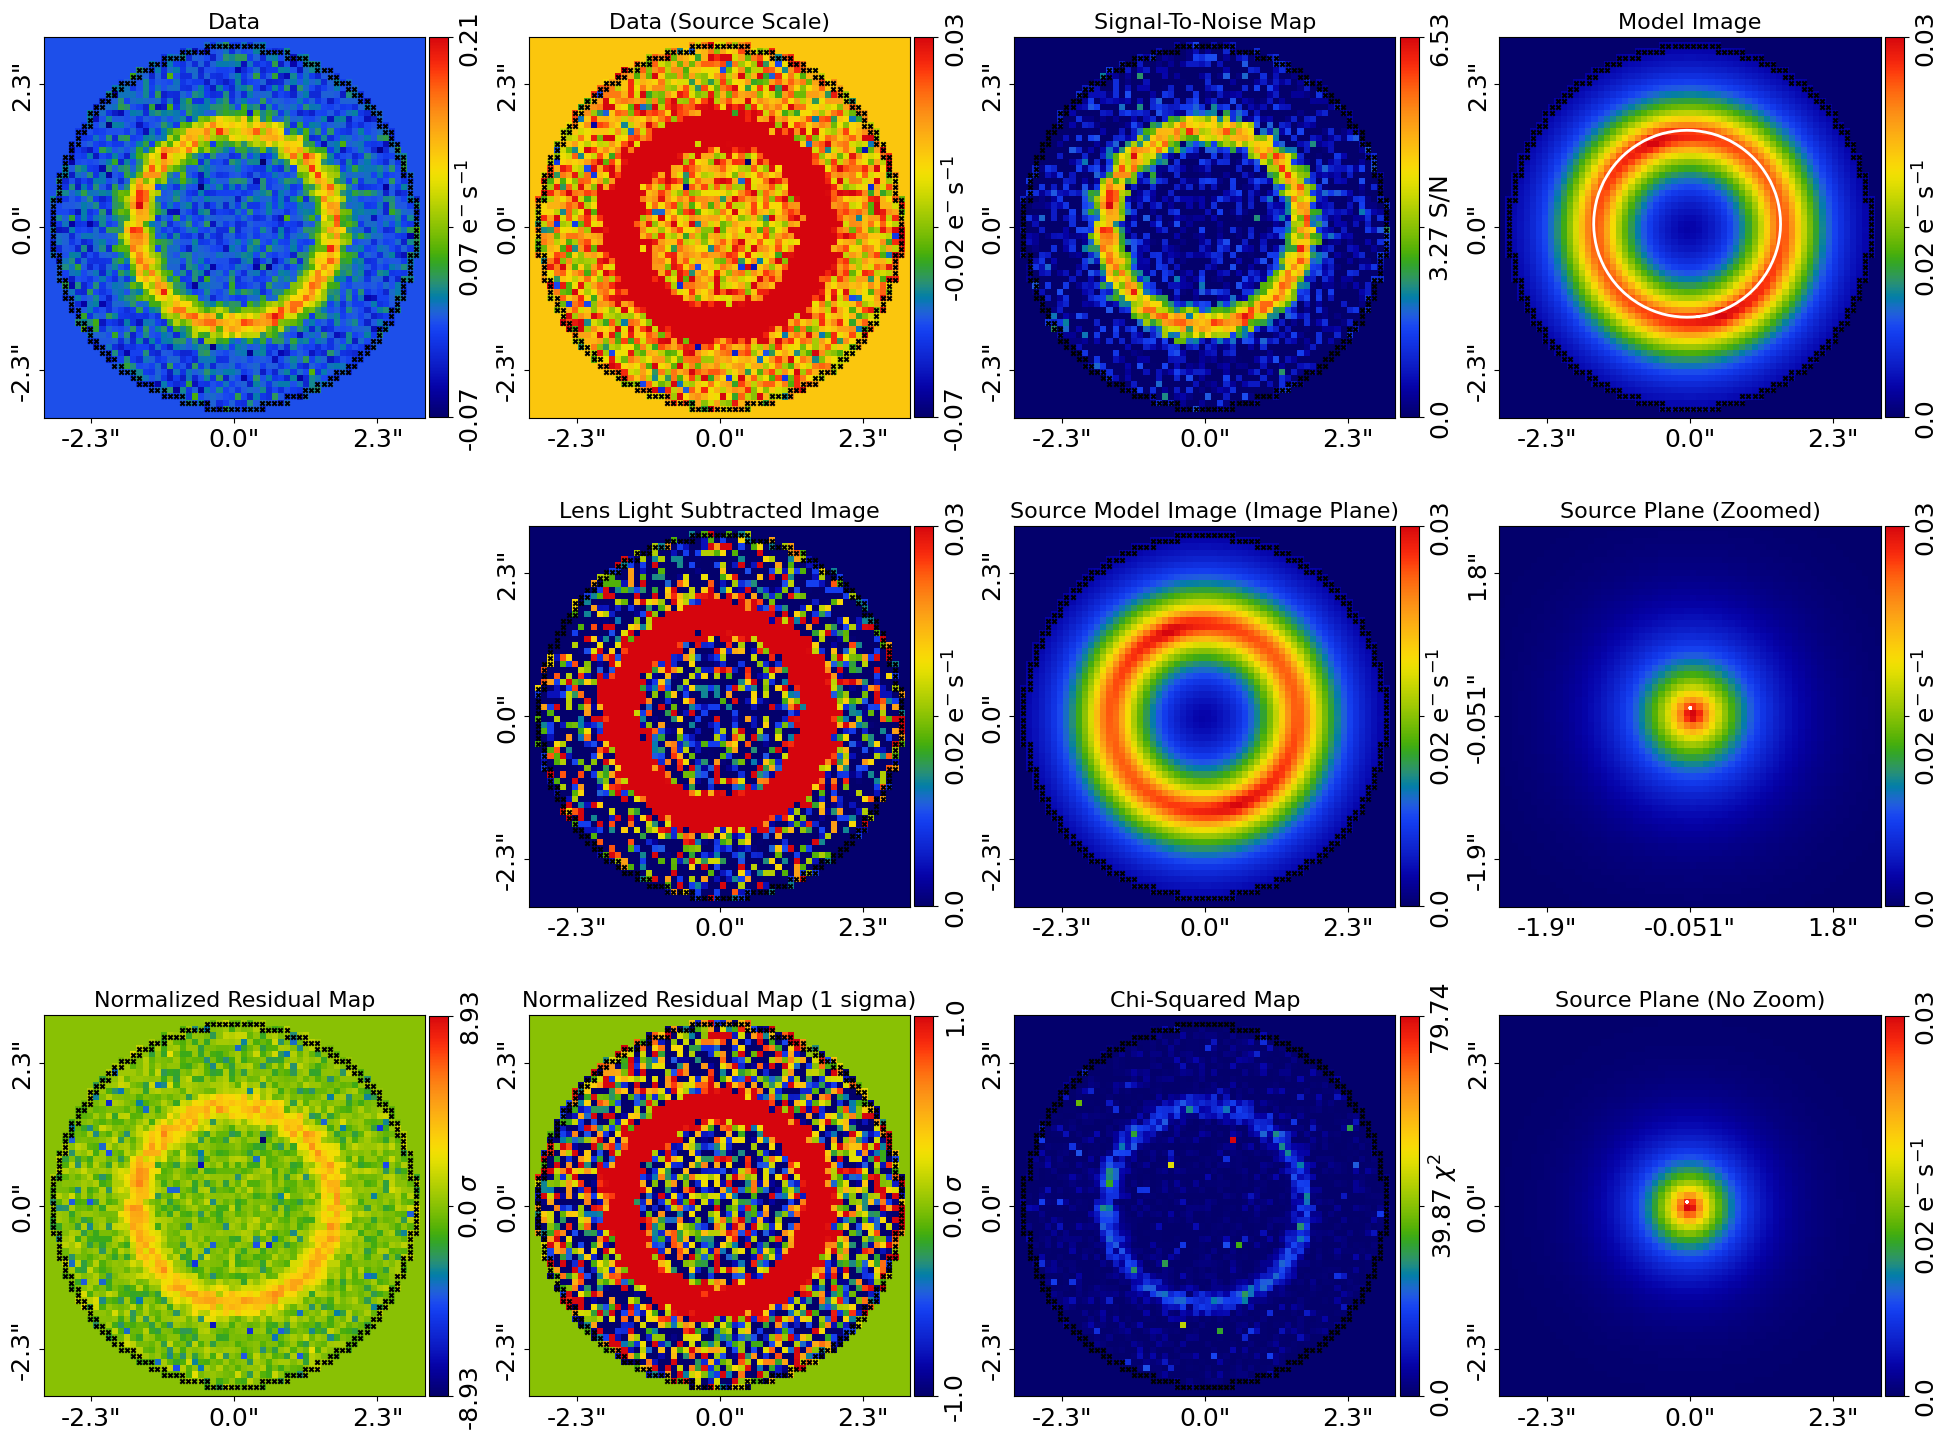

In [3]:
tracer_plotter = aplt.TracerPlotter(
    tracer=result.max_log_likelihood_tracer, grid=mask.derive_grid.all_false
)
tracer_plotter.subplot_tracer()

fit_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_plotter.subplot_fit()

__Samples__

The result contains a lot more information about the model-fit. 

For example, the `Samples` object contains all of the non-linear search samples, including the parameters 
of every successful lens model evaluation and their log likelihood values. These are used for computing information 
about the model-fit, such as the most probably parameter estimates and the error inferred for every parameter.

In [4]:
print(result.samples)
print("Parameters of 1st Sample:")
print(result.samples.parameter_lists[0][:])
print("Log Likelihood of 1st Sample:")
print(result.samples.log_likelihood_list[0])

SamplesNest(6949)
Parameters of 1st Sample:
[-0.001388812256819918, -0.008047631822897803, 1.766372570712778, 0.607030284415973, -0.1790226805530367, 20.031802990884934, 0.09368479307130657]
Log Likelihood of 1st Sample:
-17809.769036292575


__Workspace__

We are not going into any more detail on the result variable in this tutorial, or in the **HowToLens**  lectures.

A comprehensive description of the results can be found at the following package:

 `autolens_workspace/*/results`
 
The results API for CCD imaging data is the same as for other data types (e.g. interferometer, point-soures). This
package can therefore be used to learn the API and then translate to other data types.


__Database__

Once a search has completed running, we have a set of results on our hard disk which we can manually inspect and 
analyse. Alternatively, we can return the results from the search.fit() method and manipulate them in a Python script
or notebook.  

However, imagine you have a large dataset consisting of many images of strong lenses. You analyse each image 
individually using a search, producing a large library of results on your hard disk. There will be lots of paths and 
directories to navigate, and at some point there will simply be too many results for it to be an efficient use of your 
time to analyse the results by sifting through the outputs on your hard disk one-by-one.

**PyAutoLens**'s database tools solve this problem, by making it possible for us to write the results to a .sqlite 
database file and load the results from hard-disk to a Python script or Jupyter notebook. This database supports
advanced queries, so specific results can be loaded and inspected.

We won't go into any more detail on the database in this tutorial. If you think the database will be useful, checkout 
the full set of database tutorials which can be found in the folder `autolens_workspace/*/imaging/advanced/database`. 

Here, you'll learn how to:

 - Use the database to query for results which fit a certain lens model or give a certain result. 
 
 - Use the `Samples` to produce many different results from the fit, including error estimates on parameters and 
 plots of the probability density function of parameters in 1D and 2D.
 
 - Visualize results, for example the fit to a lens dataset.

__Wrap Up__

Even if you are only modeling a small sample of lenses, if you anticipate using **PyAutoLens** for the long-term I 
strongly recommend you begin using the database to inspect and analyse your result. 

This is because it makes it simple to perform all analyse in a Jupyter notebook, which is the most flexible and 
versatile way to check results and make figures.